# Extract polygons of italian cities from [ISTAT](https://www.istat.it/notizia/confini-delle-unita-amministrative-a-fini-statistici-al-1-gennaio-2018-2/)

When extracting the polygons for european cities with >100k citizens from OpenStreetMap (see notebook `check_polygons.ipynb`), some polygons were found to be too big. 

This was the case for 27 Italian cities.

Italy's [statistical regions](https://en.wikipedia.org/wiki/NUTS_statistical_regions_of_Italy) are:
- Ripartizione Geografica = NUTS I
- Regioni = NUTS II
- Province = NUTS III
- Comuni

## Setup

In [88]:
import requests
from shapely import Polygon, MultiPolygon
from shapely.geometry import shape
import matplotlib.pyplot as plt
import geopandas as gpd
import contextily as cx
import textwrap # for long titles
import os
from shapely.ops import unary_union
import pandas as pd
import osmnx as ox

## Import Italian geografic regions

Data is downloadable at: [Limiti01012026](https://www.istat.it/storage/cartografia/confini_amministrativi/non_generalizzati/2026/Limiti01012026.zip)


Description of the columns in the different files:

|   Column  |                                              Meaning                                             |
|:---------:|:------------------------------------------------------------------------------------------------:|
| COD_RIP   | Code of the geographic zone (NUTS I), from 1-5                                                   |
| DEN_RIP   | Name of the geographic zone (NUTS I)                                                             |
| COD_REG   | Code of the region (NUTS II), from 1-20                                                          |
| DEN_REG   | Name of the region (NUTS II)                                                                     |
| COD_PROV  | Code of the province (NUTS III), from 1-119                                                      |
| DEN_PROV  | Name of the province (NUTS III)                                                                  |
| COD_CM    | Code of the metropolitan area (adds 200 to COD_PROV)                                             |
| DEN_CM    | Name of the main city of the metropolitan area                                                   |
| COD_UTS   | Code of the metropolitan area of the city if there is one, else the code of the province         |
| DEN_UTS   | Name of the main city of the metropolitan area if there is one, else the name of the province    |
| SIGLA     | Automobile abbreviation                                                                          |
| PRO_COM   | Code of the municipality (code of province + code of city)                                       |
| PRO_COM_T | Code of the municipality (code of province + code of city), with fixed length                    |
| COMUNE    | Name of the municipality                                                                         |
| COMUNE_A  | Name of the municipality in another language (e.g.: for cities bordering Slovenia, and Germany)  |
| CC_UTS    | 1 if city is the capital of a province, 0 otherwise                                              |

In [89]:
path_prefix = "../cities/development/Limiti01012026"

ripgeo = gpd.read_file(f"{path_prefix}/RipGeo01012026/RipGeo01012026_WGS84.shp", encoding="utf-8")
regioni = gpd.read_file(f"{path_prefix}/Reg01012026/Reg01012026_WGS84.shp", encoding="utf-8")
province = gpd.read_file(f"{path_prefix}/ProvCM01012026/ProvCM01012026_WGS84.shp", encoding="utf-8")
comuni = gpd.read_file(f"{path_prefix}/Com01012026/Com01012026_WGS84.shp", encoding="utf-8")

In [49]:
ripgeo

,COD_RIP,DEN_RIP,Shape_Leng,Shape_Area,geometry
0,1,Nord-ovest,2.712737e+06,5.792828e+10,"MULTIPOLYGON (((568231.969 4874857.994, 568233..."
1,2,Nord-est,2.588251e+06,6.239505e+10,"MULTIPOLYGON (((618335.21 4893983.16, 618329.9..."
2,3,Centro,2.436330e+06,5.803939e+10,"MULTIPOLYGON (((875824.766 4525269.843, 875835..."
3,4,Sud,3.290598e+06,7.380319e+10,"MULTIPOLYGON (((1099201.423 4270181.967, 10991..."
4,5,Isole,3.948322e+06,4.994385e+10,"MULTIPOLYGON (((822779.053 3935557.494, 822772..."


In [50]:
regioni

,COD_RIP,COD_REG,DEN_REG,Shape_Leng,Shape_Area,geometry
0,1,1,Piemonte,1.333399e+06,2.538673e+10,"POLYGON ((456874.627 5145767.794, 456879.628 5..."
1,1,2,Valle d'Aosta/Vallée d'Aoste,3.258360e+05,3.260843e+09,"POLYGON ((389358.652 5093659.158, 389433.654 5..."
2,1,3,Lombardia,1.511122e+06,2.386309e+10,"MULTIPOLYGON (((485366.17 4984899.483, 485306...."
3,2,4,Trentino-Alto Adige/Südtirol,8.599699e+05,1.360470e+10,"POLYGON ((743387.812 5219741.792, 743414.748 5..."
4,2,5,Veneto,1.163721e+06,1.835524e+10,"POLYGON ((768136.788 5175349.943, 768146.459 5..."
5,2,6,Friuli-Venezia Giulia,7.744607e+05,7.933296e+09,"MULTIPOLYGON (((870657.845 5067641.461, 870660..."
6,1,7,Liguria,1.121496e+06,5.417623e+09,"MULTIPOLYGON (((568231.969 4874857.994, 568233..."
7,2,8,Emilia-Romagna,1.284836e+06,2.250181e+10,"MULTIPOLYGON (((618335.21 4893983.16, 618329.9..."
8,3,9,Toscana,1.553594e+06,2.298980e+10,"MULTIPOLYGON (((673999.895 4681200.359, 674015..."
9,3,10,Umbria,6.714091e+05,8.464203e+09,"MULTIPOLYGON (((776441.887 4834151.253, 776480..."


In [51]:
province

,COD_RIP,COD_REG,COD_PROV,COD_CM,COD_UTS,DEN_PROV,DEN_CM,DEN_UTS,SIGLA,TIPO_UTS,Shape_Leng,Shape_Area,geometry
0,1,1,1,201,201,-,Torino,Torino,TO,Città metropolitana,593230.438256,6.826930e+09,"POLYGON ((411015.294 5049971.205, 411070.286 5..."
1,1,1,2,0,2,Vercelli,-,Vercelli,VC,Provincia,458711.479193,2.081605e+09,"POLYGON ((437906.609 5088793.96, 437911.685 50..."
2,1,1,3,0,3,Novara,-,Novara,NO,Provincia,276706.922997,1.340248e+09,"POLYGON ((459146.455 5079451.255, 459180.781 5..."
3,1,1,4,0,4,Cuneo,-,Cuneo,CN,Provincia,542032.100362,6.894823e+09,"MULTIPOLYGON (((378934.647 4958535.662, 378939..."
4,1,1,5,0,5,Asti,-,Asti,AT,Provincia,356340.593667,1.510173e+09,"POLYGON ((423634.299 4998152.372, 423642.985 4..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
105,5,20,115,0,115,Oristano,-,Oristano,OR,Provincia,451298.418591,2.991434e+09,"MULTIPOLYGON (((438077.218 4414949.33, 438083...."
106,5,20,116,0,116,Ogliastra,-,Ogliastra,OG,Provincia,262269.375886,1.855583e+09,"MULTIPOLYGON (((557580.89 4395132.994, 557571...."
107,5,20,117,0,117,Medio Campidano,-,Medio Campidano,VS,Provincia,262967.100805,1.517634e+09,"POLYGON ((495936.465 4403116.294, 495976.509 4..."
108,5,20,118,318,318,-,Cagliari,Cagliari,CA,Città metropolitana,578972.160683,4.311468e+09,"MULTIPOLYGON (((488357.189 4303685.645, 488343..."


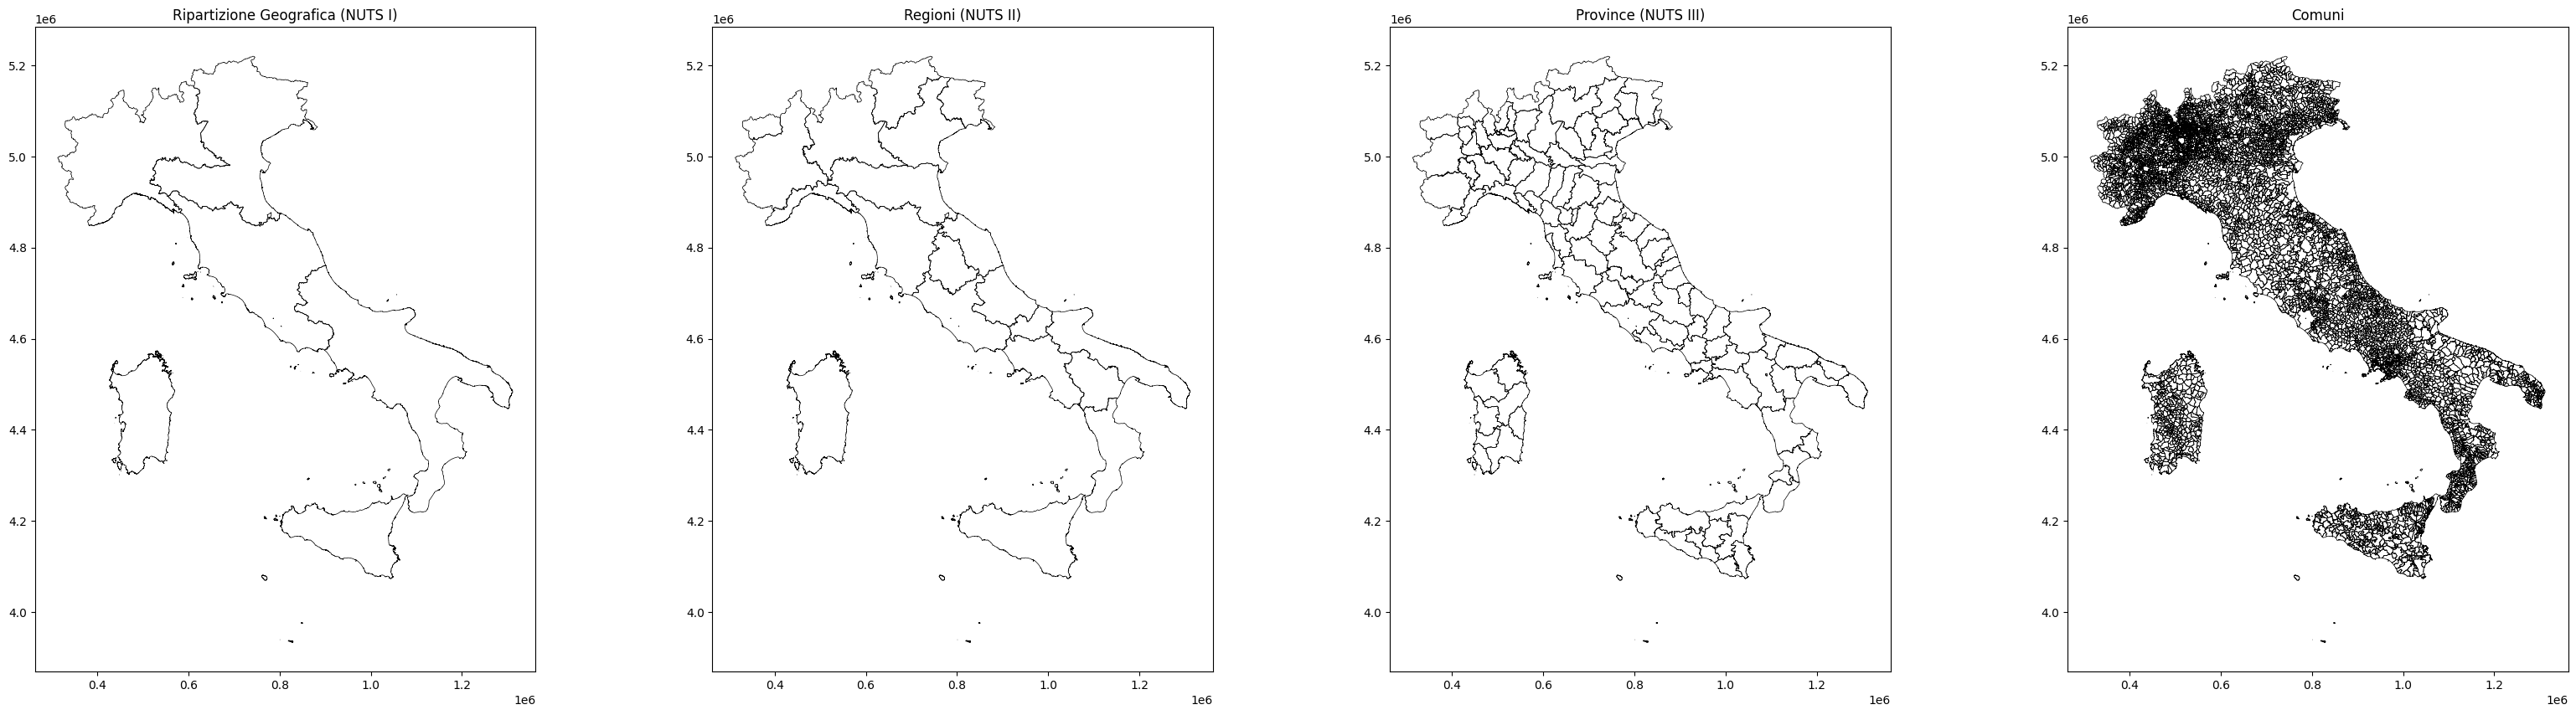

In [10]:
fig, axes = plt.subplots(
    figsize=(40,10),
    ncols = 4,
    nrows = 1
)

ax = axes.flatten()

ripgeo.plot(
    ax = ax[0],
    facecolor="none",       
    edgecolor="black",        
    linestyle="-",         
    linewidth=0.5
)
ax[0].set_title("Ripartizione Geografica (NUTS I)")

regioni.plot(
    ax = ax[1],
    facecolor="none",       
    edgecolor="black",        
    linestyle="-",         
    linewidth=0.5
)
ax[1].set_title("Regioni (NUTS II)")

province.plot(
    ax = ax[2],
    facecolor="none",       
    edgecolor="black",        
    linestyle="-",         
    linewidth=0.5
)
ax[2].set_title("Province (NUTS III)")

comuni.plot(
    ax = ax[3],
    facecolor="none",       
    edgecolor="black",        
    linestyle="-",         
    linewidth=0.5
)
ax[3].set_title("Comuni")

plt.show()

## Import "unaccepted" Italian cities

In [90]:
european_100000pop = pd.read_excel(
    '../cities/development/european_100000pop_comments.xlsx',
    sheet_name = 'Comments',
    usecols = "A:C,E:F,H"
    ).query("accepted == 0 & country_en == 'Italy'").drop(columns = ['accepted']).sort_values(by=['name_en', 'country_en']).reset_index(drop=True).set_index('name_en')
european_100000pop

,country_en,nominatim_query,alpha-2,population
name_en,,,,
Bolzano,Italy,"Bolzano, Bolzano",IT,107034
Catania,Italy,Catania,IT,300730
Ferrara,Italy,"Ferrara, Ferrara",IT,130771
Foggia,Italy,"Foggia, Foggia",IT,147135
Forli,Italy,"Forli, Forli",IT,116983
Genoa,Italy,Genoa,IT,563807
Giugliano In Campania,Italy,Giugliano In Campania,IT,123061
Latina,Italy,"Latina, Latina",IT,127711
Modena,Italy,"Modena, Modena",IT,185693


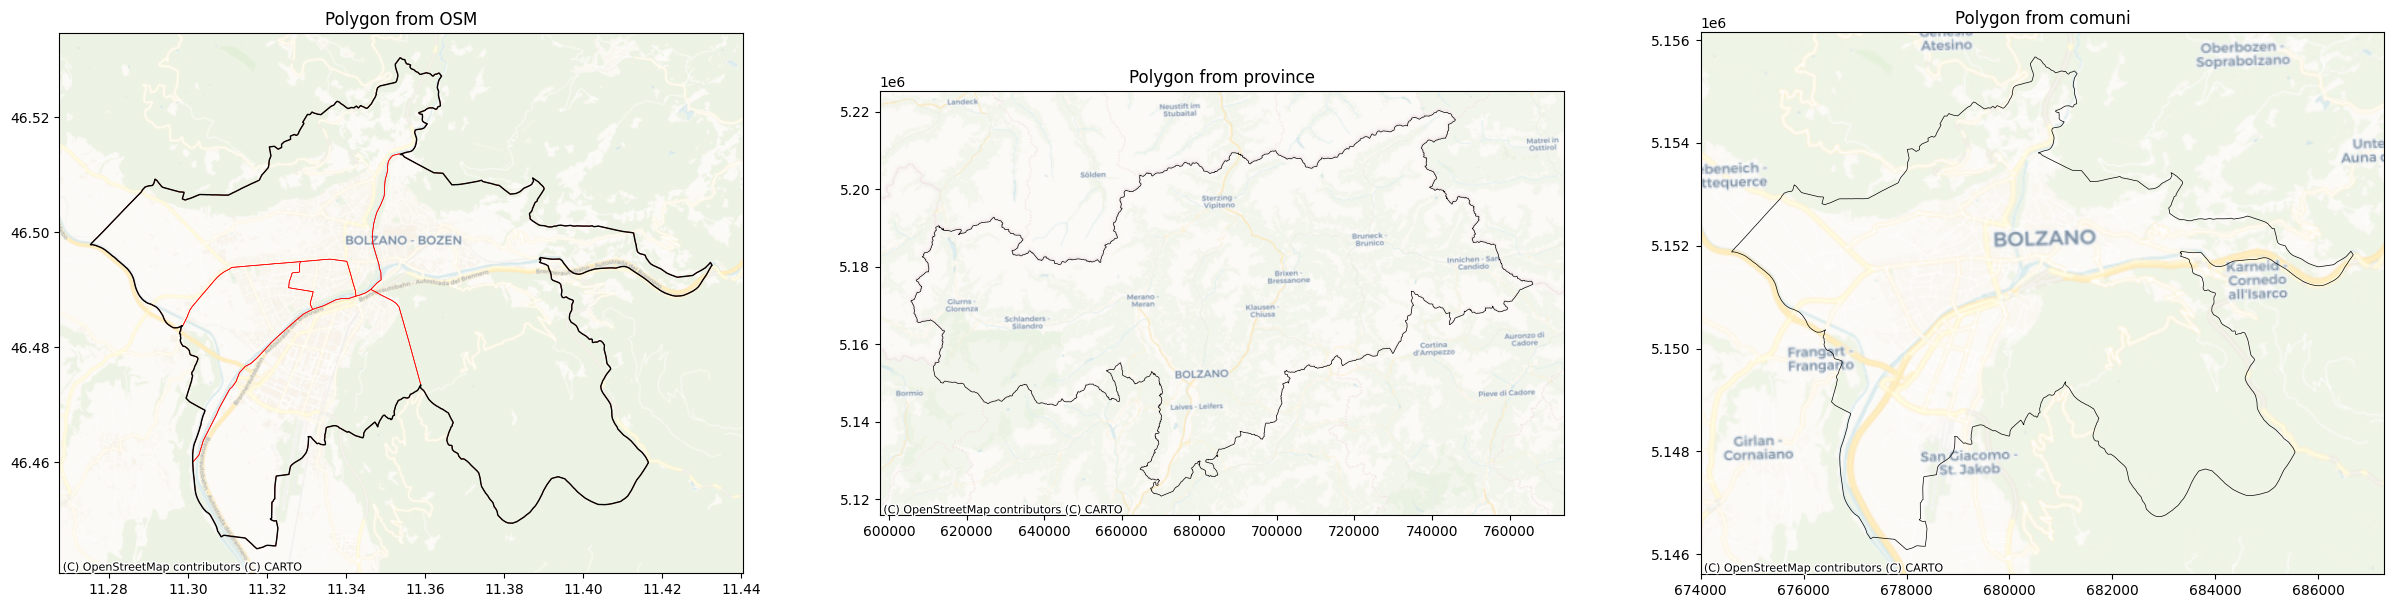

In [91]:
city = "Bolzano"

osm = ox.geocoder.geocode_to_gdf(european_100000pop.loc[city,'nominatim_query'])

prov = province.query(f"DEN_UTS.str.contains('{city}', case=False, na=False)")
com = comuni.query(f"COMUNE.str.contains('{city}', case=False, na=False)").nlargest(1, "Shape_Area")

osm_poly = osm.geometry.iloc[0]
tags = {
    'boundary': 'administrative',
    'admin_level': '10'  
}
subdivisions = ox.features_from_polygon(osm_poly, tags=tags).query("admin_level == '10'")
clipped_subdivisions = gpd.clip(subdivisions, osm_poly)
clipped_subdivisions = clipped_subdivisions[
    clipped_subdivisions.geometry.type.isin(['Polygon', 'MultiPolygon'])
]



fig, axes = plt.subplots(
    figsize=(30,10),
    ncols = 3,
    nrows = 1
)

ax = axes.flatten()

clipped_subdivisions.plot(
    ax = ax[0],
    facecolor="none",       
    edgecolor="red",        
    linestyle="-",         
    linewidth=0.5
)
osm.plot(
    ax = ax[0],
    facecolor="none",       
    edgecolor="black",        
    linestyle="-",         
    linewidth=1
)
ax[0].set_title("Polygon from OSM")
cx.add_basemap(ax[0], crs=osm.crs, source=cx.providers.CartoDB.Voyager, alpha = 0.7)

prov.plot(
    ax = ax[1],
    facecolor="none",       
    edgecolor="black",        
    linestyle="-",         
    linewidth=0.5
)
ax[1].set_title("Polygon from province")
cx.add_basemap(ax[1], crs=prov.crs, source=cx.providers.CartoDB.Voyager, alpha = 0.7)

com.plot(
    ax = ax[2],
    facecolor="none",       
    edgecolor="black",        
    linestyle="-",         
    linewidth=0.5
)
ax[2].set_title("Polygon from comuni")
cx.add_basemap(ax[2], crs=com.crs, source=cx.providers.CartoDB.Voyager, alpha = 0.7)

plt.show()

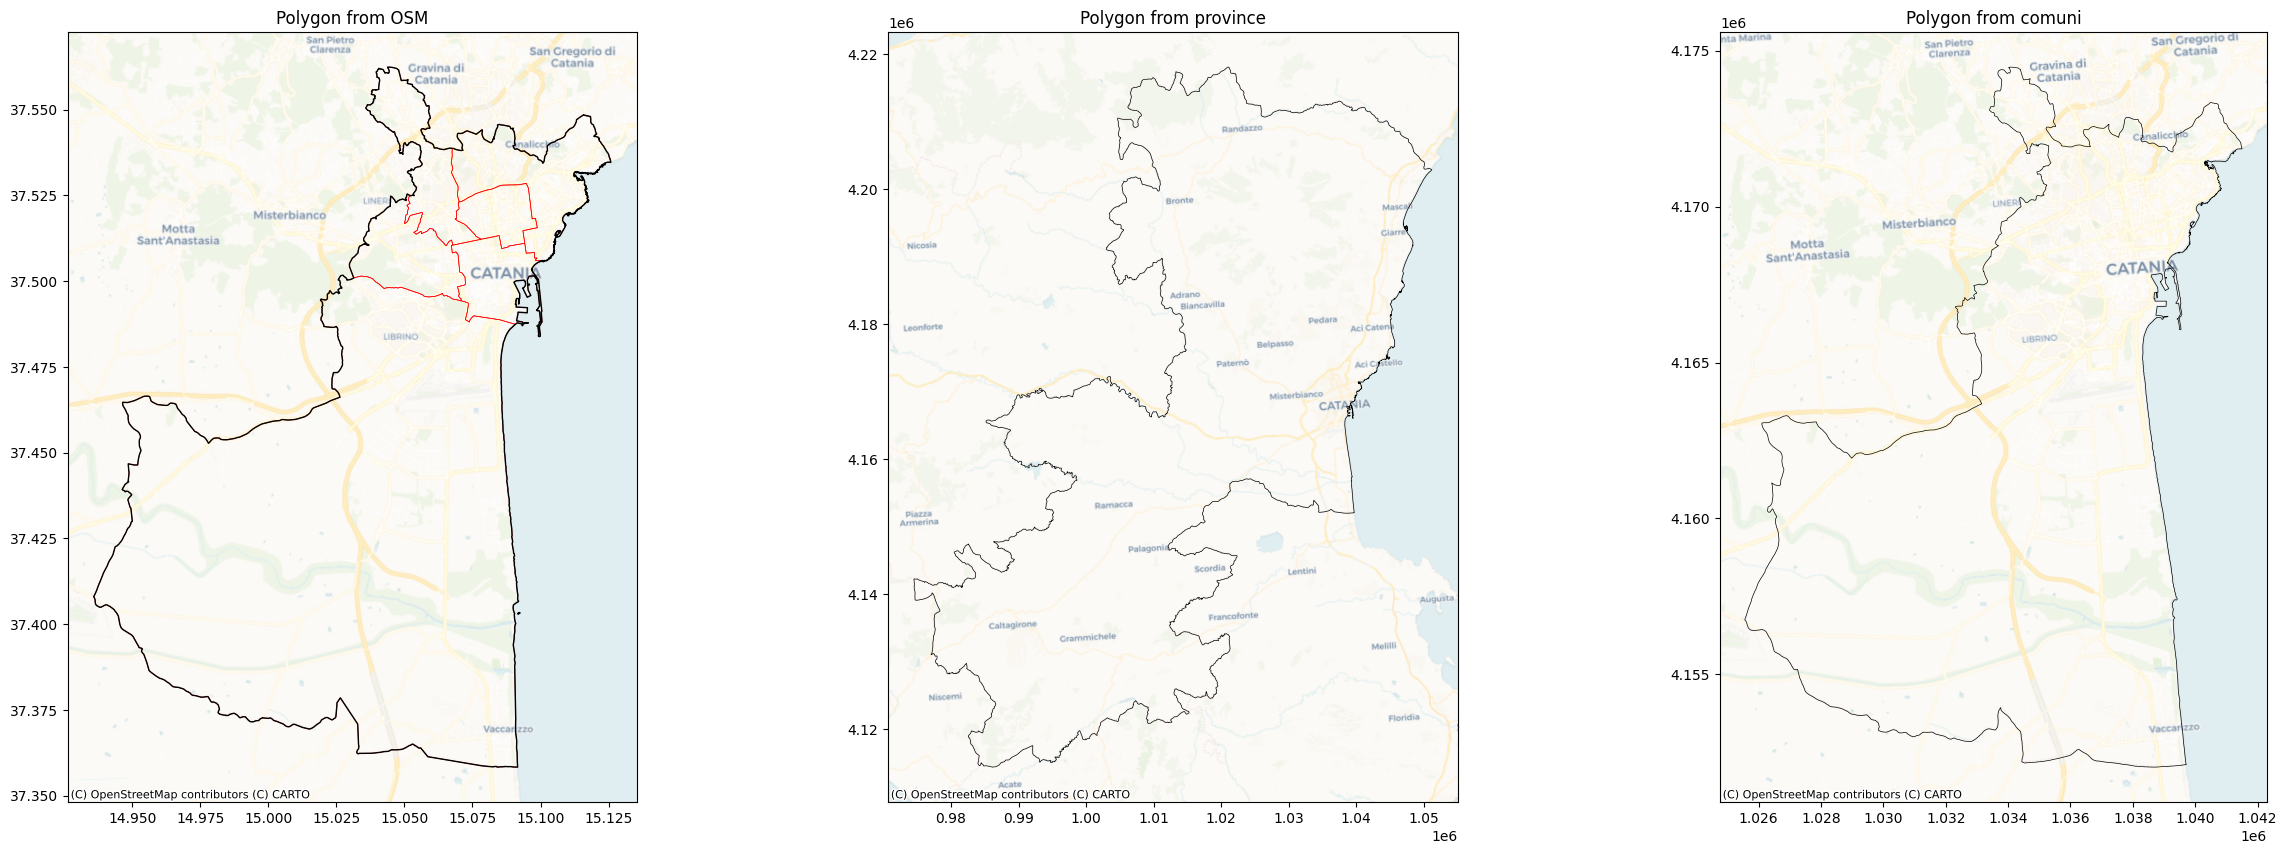

In [92]:
city = "Catania"

osm = ox.geocoder.geocode_to_gdf(european_100000pop.loc[city,'nominatim_query'])

prov = province.query(f"DEN_UTS.str.contains('{city}', case=False, na=False)")
com = comuni.query(f"COMUNE.str.contains('{city}', case=False, na=False)").nlargest(1, "Shape_Area")

osm_poly = osm.geometry.iloc[0]
tags = {
    'boundary': 'administrative',
    'admin_level': '10'  
}
subdivisions = ox.features_from_polygon(osm_poly, tags=tags).query("admin_level == '10'")
clipped_subdivisions = gpd.clip(subdivisions, osm_poly)
clipped_subdivisions = clipped_subdivisions[
    clipped_subdivisions.geometry.type.isin(['Polygon', 'MultiPolygon'])
]



fig, axes = plt.subplots(
    figsize=(30,10),
    ncols = 3,
    nrows = 1
)

ax = axes.flatten()

clipped_subdivisions.plot(
    ax = ax[0],
    facecolor="none",       
    edgecolor="red",        
    linestyle="-",         
    linewidth=0.5
)
osm.plot(
    ax = ax[0],
    facecolor="none",       
    edgecolor="black",        
    linestyle="-",         
    linewidth=1
)
ax[0].set_title("Polygon from OSM")
cx.add_basemap(ax[0], crs=osm.crs, source=cx.providers.CartoDB.Voyager, alpha = 0.7)

prov.plot(
    ax = ax[1],
    facecolor="none",       
    edgecolor="black",        
    linestyle="-",         
    linewidth=0.5
)
ax[1].set_title("Polygon from province")
cx.add_basemap(ax[1], crs=prov.crs, source=cx.providers.CartoDB.Voyager, alpha = 0.7)

com.plot(
    ax = ax[2],
    facecolor="none",       
    edgecolor="black",        
    linestyle="-",         
    linewidth=0.5
)
ax[2].set_title("Polygon from comuni")
cx.add_basemap(ax[2], crs=com.crs, source=cx.providers.CartoDB.Voyager, alpha = 0.7)

plt.show()

In [86]:
clipped_subdivisions

geometry  \
element  id                                                            
relation 10923497  POLYGON ((11.30282 46.46124, 11.30393 46.46376...   
         10923496  POLYGON ((11.29868 46.48372, 11.29878 46.4838,...   
         10923498  POLYGON ((11.34786 46.49118, 11.34889 46.49173...   
         10923495  POLYGON ((11.32553 46.49046, 11.32555 46.49066...   
         10923494  POLYGON ((11.27566 46.49808, 11.27569 46.4981,...   

                         boundary admin_level name:left name:right source  \
element  id                                                                 
relation 10923497  administrative          10       NaN        NaN    NaN   
         10923496  administrative          10       NaN        NaN    NaN   
         10923498  administrative          10       NaN        NaN    NaN   
         10923495  administrative          10       NaN        NaN    NaN   
         10923494  administrative          10       NaN        NaN    NaN   

                                                                name  \
element  id                                                            
relation 10923497                 Oltrisarco-Aslago - Oberau-Haslach   
         10923496                                          Don Bosco   
         10923498  Centro-Piani-Rencio - Zentrum-Bozner Boden-Ren...   
         10923495                 Europa-Novacella - Europa-Neustift   
         10923494                  Gries-San Quirino - Gries-Quirein   

                                        name:de name:en name:fr  ...  \
element  id                                                      ...   
relation 10923497                Oberau-Haslach     NaN     NaN  ...   
         10923496                     Don Bosco     NaN     NaN  ...   
         10923498  Zentrum-Bozner Boden-Rentsch     NaN     NaN  ...   
         10923495               Europa-Neustift     NaN     NaN  ...   
         10923494                 Gries-Quirein     NaN     NaN  ...   

                  ref:nuts:3 short_name admin_centre:postal_code ref:catasto  \
element  id                                                                    
relation 10923497        NaN        NaN                      NaN         NaN   
         10923496        NaN        NaN                      NaN         NaN   
         10923498        NaN        NaN                      NaN         NaN   
         10923495        NaN        NaN                      NaN         NaN   
         10923494        NaN        NaN                      NaN         NaN   

                  place population short_name:de short_name:it coat_of_arms  \
element  id                                                                   
relation 10923497   NaN        NaN           NaN           NaN          NaN   
         10923496   NaN        NaN           NaN           NaN          NaN   
         10923498   NaN        NaN           NaN           NaN          NaN   
         10923495   NaN        NaN           NaN           NaN          NaN   
         10923494   NaN        NaN           NaN           NaN          NaN   

                  flag  
element  id             
relation 10923497  NaN  
         10923496  NaN  
         10923498  NaN  
         10923495  NaN  
         10923494  NaN  

[5 rows x 51 columns]

# Conclusion

The units smaller than municipalities don't correspond to the ones in the Google Maps, so they are not considered.